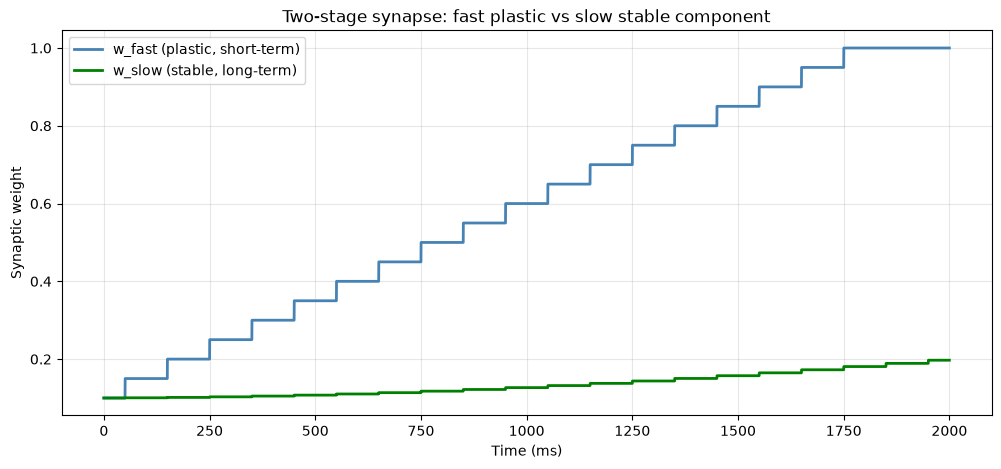

Final w_fast: 1.0000
Final w_slow: 0.1971
Output spikes: 8


In [2]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# TWO-STAGE SYNAPSE MODEL
# w_fast: plastic component — changes easily, represents working/short-term memory
# w_slow: stable component — updates gradually from w_fast, represents long-term memory
# Based on the synaptic tagging and capture hypothesis

tau_mem = 10*ms
tau_fast = 50*ms    # fast component decays quickly if not consolidated
tau_slow = 2000*ms  # slow component changes very gradually and represents consolidation

# Single output neuron
eqs = '''
dv/dt = -v/tau_mem : 1
'''
output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')

# Input neuron fires repeatedly to drive learning
input_times = np.arange(50, 2001, 100)*ms  # fires every 100ms
input_neuron = SpikeGeneratorGroup(1, [0]*len(input_times), input_times)

# Two-stage synapse equations
synapse_eqs = '''
w_fast : 1    # fast plastic component
w_slow : 1    # slow stable component
'''

on_pre = '''
v_post += w_fast + w_slow
w_fast = clip(w_fast + 0.05, 0, 1)
w_slow += 0.01 * (w_fast - w_slow)
'''

S = Synapses(input_neuron, output, synapse_eqs, on_pre=on_pre)
S.connect()
S.w_fast = 0.1
S.w_slow = 0.1

# Monitor both components
fast_mon = StateMonitor(S, 'w_fast', record=True)
slow_mon = StateMonitor(S, 'w_slow', record=True)
spike_mon = SpikeMonitor(output)

run(2*second)

plt.figure(figsize=(12, 5))
plt.plot(fast_mon.t/ms, fast_mon.w_fast[0], 
         color='steelblue', linewidth=2, label='w_fast (plastic, short-term)')
plt.plot(slow_mon.t/ms, slow_mon.w_slow[0], 
         color='green', linewidth=2, label='w_slow (stable, long-term)')
plt.xlabel('Time (ms)')
plt.ylabel('Synaptic weight')
plt.title('Two-stage synapse: fast plastic vs slow stable component')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final w_fast: {S.w_fast[0]:.4f}")
print(f"Final w_slow: {S.w_slow[0]:.4f}")
print(f"Output spikes: {len(spike_mon.t)}")

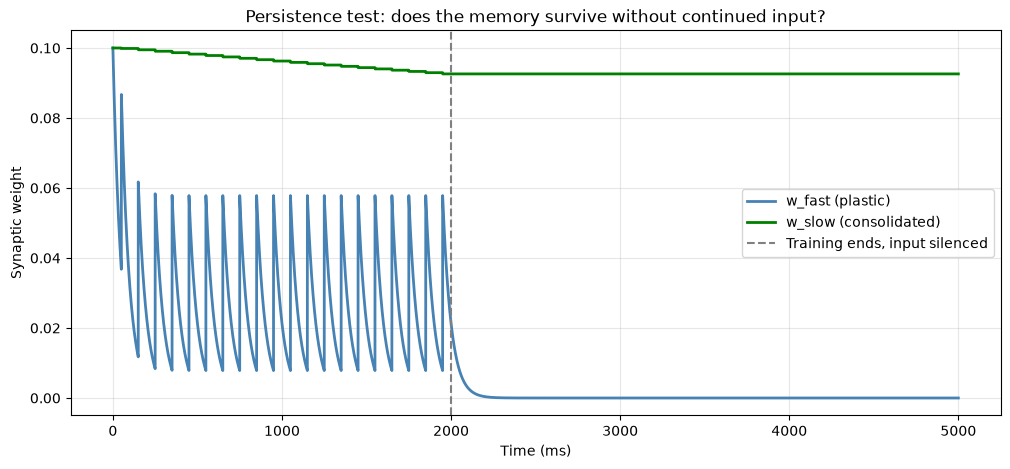

w_fast at training end (t=2000ms): 0.0213
w_fast at end of silence (t=5000ms): 0.0000
w_slow at training end (t=2000ms): 0.0926
w_slow at end of silence (t=5000ms): 0.0926


In [3]:
start_scope()

tau_mem = 10*ms
tau_fast = 50*ms
tau_slow = 2000*ms

eqs = '''
dv/dt = -v/tau_mem : 1
'''
output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')

# Training phase: input fires for first 2000ms only
input_times = np.arange(50, 2001, 100)*ms
input_neuron = SpikeGeneratorGroup(1, [0]*len(input_times), input_times)

synapse_eqs = '''
w_fast : 1
w_slow : 1
dw_fast_decay/dt = -w_fast/tau_fast : 1 (clock-driven)
'''

# Actually, let's model decay properly with continuous dynamics
synapse_eqs = '''
dw_fast/dt = -w_fast/tau_fast : 1 (clock-driven)
w_slow : 1
'''

on_pre = '''
v_post += w_fast + w_slow
w_fast = clip(w_fast + 0.05, 0, 1)
w_slow += 0.01 * (w_fast - w_slow)
'''

S = Synapses(input_neuron, output, synapse_eqs, on_pre=on_pre, method='exact')
S.connect()
S.w_fast = 0.1
S.w_slow = 0.1

fast_mon = StateMonitor(S, 'w_fast', record=True)
slow_mon = StateMonitor(S, 'w_slow', record=True)

# Run for 2s of training, then 3s more with NO input (silence) to test persistence
run(5*second)

plt.figure(figsize=(12, 5))
plt.plot(fast_mon.t/ms, fast_mon.w_fast[0], 
         color='steelblue', linewidth=2, label='w_fast (plastic)')
plt.plot(slow_mon.t/ms, slow_mon.w_slow[0], 
         color='green', linewidth=2, label='w_slow (consolidated)')
plt.axvline(x=2000, color='gray', linestyle='--', label='Training ends, input silenced')
plt.xlabel('Time (ms)')
plt.ylabel('Synaptic weight')
plt.title('Persistence test: does the memory survive without continued input?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"w_fast at training end (t=2000ms): {fast_mon.w_fast[0][int(2000/0.1)]:.4f}")
print(f"w_fast at end of silence (t=5000ms): {fast_mon.w_fast[0][-1]:.4f}")
print(f"w_slow at training end (t=2000ms): {slow_mon.w_slow[0][int(2000/0.1)]:.4f}")
print(f"w_slow at end of silence (t=5000ms): {slow_mon.w_slow[0][-1]:.4f}")

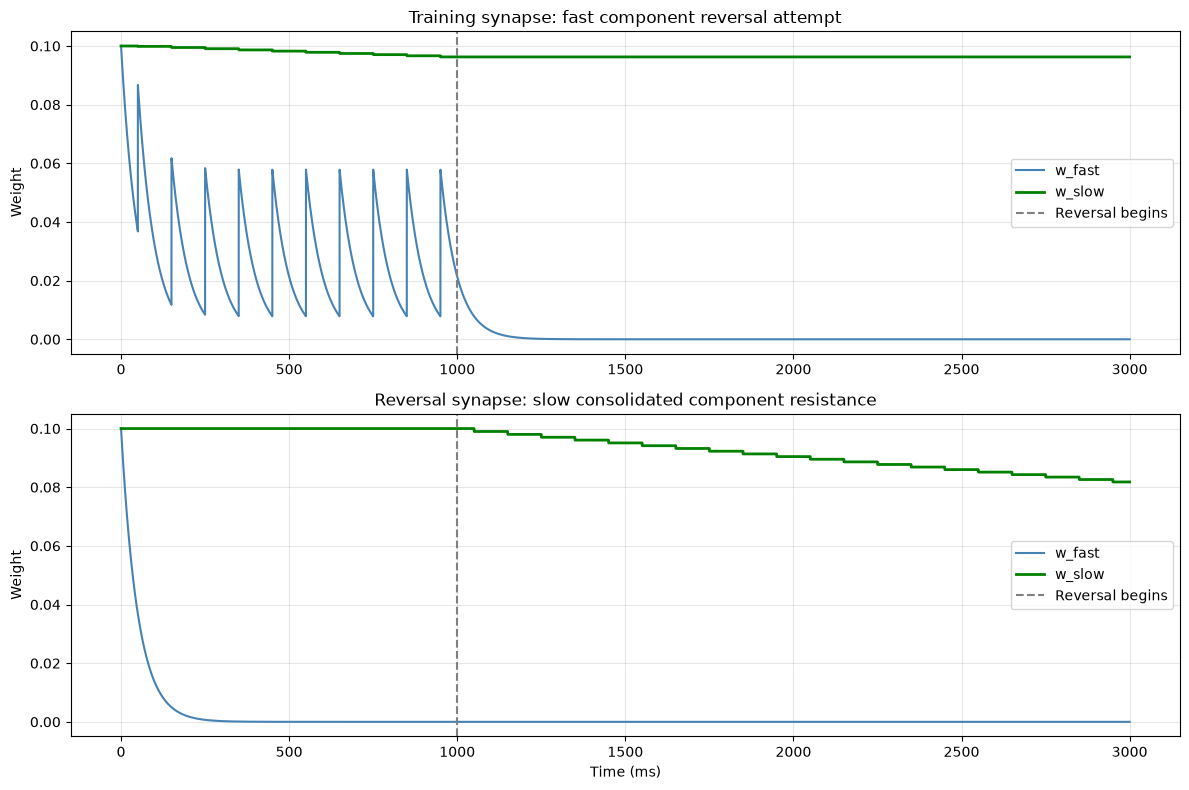

Training synapse — w_slow at reversal start: 0.0963
Training synapse — w_slow at end: 0.0963
Reversal synapse — w_slow at reversal start: 0.1000
Reversal synapse — w_slow at end: 0.0818


In [4]:
start_scope()

tau_mem = 10*ms
tau_fast = 50*ms

eqs = '''
dv/dt = -v/tau_mem : 1
'''
output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')

# Phase 1: Training (0-1000ms) — build up the memory
# Phase 2: Reversal attempt (1000-3000ms) — try to unlearn it

# Training input fires every 100ms for first 1000ms
train_times = np.arange(50, 1001, 100)*ms

# Reversal: depression signal every 100ms from 1000-3000ms
# (simulates trying to weaken the synapse)
reversal_times = np.arange(1050, 3001, 100)*ms

input_train = SpikeGeneratorGroup(1, [0]*len(train_times), train_times)
input_reversal = SpikeGeneratorGroup(1, [0]*len(reversal_times), reversal_times)

synapse_eqs = '''
dw_fast/dt = -w_fast/tau_fast : 1 (clock-driven)
w_slow : 1
'''

on_pre_train = '''
v_post += w_fast + w_slow
w_fast = clip(w_fast + 0.05, 0, 1)
w_slow += 0.01 * (w_fast - w_slow)
'''

on_pre_reversal = '''
w_fast = clip(w_fast - 0.05, 0, 1)
w_slow += 0.01 * (w_fast - w_slow)
'''

S_train = Synapses(input_train, output, synapse_eqs, 
                   on_pre=on_pre_train, method='exact')
S_train.connect()
S_train.w_fast = 0.1
S_train.w_slow = 0.1

S_reversal = Synapses(input_reversal, output, synapse_eqs,
                      on_pre=on_pre_reversal, method='exact')
S_reversal.connect()
S_reversal.w_fast = 0.1
S_reversal.w_slow = 0.1

fast_mon_t = StateMonitor(S_train, 'w_fast', record=True)
slow_mon_t = StateMonitor(S_train, 'w_slow', record=True)
fast_mon_r = StateMonitor(S_reversal, 'w_fast', record=True)
slow_mon_r = StateMonitor(S_reversal, 'w_slow', record=True)

run(3*second)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(fast_mon_t.t/ms, fast_mon_t.w_fast[0],
         color='steelblue', linewidth=1.5, label='w_fast')
ax1.plot(slow_mon_t.t/ms, slow_mon_t.w_slow[0],
         color='green', linewidth=2, label='w_slow')
ax1.axvline(x=1000, color='gray', linestyle='--', label='Reversal begins')
ax1.set_title('Training synapse: fast component reversal attempt')
ax1.set_ylabel('Weight')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(fast_mon_r.t/ms, fast_mon_r.w_fast[0],
         color='steelblue', linewidth=1.5, label='w_fast')
ax2.plot(slow_mon_r.t/ms, slow_mon_r.w_slow[0],
         color='green', linewidth=2, label='w_slow')
ax2.axvline(x=1000, color='gray', linestyle='--', label='Reversal begins')
ax2.set_title('Reversal synapse: slow consolidated component resistance')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Weight')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training synapse — w_slow at reversal start: {slow_mon_t.w_slow[0][int(1000/0.1)]:.4f}")
print(f"Training synapse — w_slow at end: {slow_mon_t.w_slow[0][-1]:.4f}")
print(f"Reversal synapse — w_slow at reversal start: {slow_mon_r.w_slow[0][int(1000/0.1)]:.4f}")
print(f"Reversal synapse — w_slow at end: {slow_mon_r.w_slow[0][-1]:.4f}")

## Synaptic Consolidation — Observations & Results

### Why syanptic consolidation?
Synaptic consolidation explains why learned changes, whether useful skills 
or maladaptive patterns, like dopamine dysregulation, become increasingly 
resistant to reversal over time. This notebook models the transition from 
fragile short-term plasticity to stable long-term memory using a two-stage 
synapse, directly setting up Project Dopamine phase 2's investigation of 
why dysregulation is hard to reverse.

### Biological background
The **synaptic tagging and capture hypothesis** (Frey & Morris, 1997) proposes 
that synaptic changes happen in two stages:
- **Early LTP/LTD** (long-term potentiation/depression): fast, protein-synthesis 
  independent, decays without reinforcement, and equivalent to working memory
- **Late LTP/LTD**: slow, requires protein synthesis, persists indefinitely, and
  equivalent to long-term memory

A "tag" is set at the synapse during early LTP, which captures plasticity 
proteins from nearby activity to consolidate the change, and this notebook 
implements a simplified computational version of this two-stage process.

**Connection to critical periods:** children's synapses operate in heightened 
plasticity windows where consolidation happens faster and more deeply,
explaining why early experiences have disproportionate long-term effects 
compared to equivalent experiences in adulthood.

### Architecture: two-stage synapse
dw_fast/dt = -w_fast/tau_fast    # decays continuously (tau_fast=50ms)
w_slow updated on spike: w_slow += 0.01 * (w_fast - w_slow)  # slowly follows fast

- **w_fast** — plastic component: updates immediately on each spike (+0.05), 
  decays exponentially between spikes. It represents short-term, working memory.
- **w_slow** — stable component: updates only gradually toward w_fast's value. 
  No decay term — once written, persists indefinitely. It represents consolidated 
  long-term memory.

### Key finding 1: functional dissociation between fast and slow components

During 2 seconds of training (input every 100ms):
- **w_fast** oscillates in a sawtooth pattern — rising on each input spike, 
  decaying between them. Never fully accumulates due to fast decay.
- **w_slow** climbs gradually, lagging far behind w_fast.

After training ends (2000-5000ms silence):

| Component | At training end | After 3s silence | Change |
|-----------|----------------|------------------|--------|
| w_fast | 0.0213 | 0.0000 | Completely decayed |
| w_slow | 0.0926 | 0.0926 | Perfectly preserved |

**w_fast decays to zero within ~150ms of training ending. w_slow holds its 
value indefinitely.** This is the functional definition of consolidation — 
information transferred from a transient plastic state into a stable 
structural one that persists without continued reinforcement.

### Key finding 2: consolidated memory resists reversal

After 1000ms of training, an active reversal signal (depression, -0.05 per 
spike) was applied for 2000ms — twice the training duration.

| Synapse | w_slow before reversal | w_slow after 2s reversal | Change |
|---------|----------------------|--------------------------|--------|
| Trained (consolidated) | 0.0963 | 0.0963 | 0.0000 — complete resistance |
| Untrained (baseline) | 0.1000 | 0.0818 | 0.0182 — partial change |

The consolidated synapse showed **zero response** to 2 seconds of active 
reversal (w_slow didn't move at all), while the untrained baseline synapse moved 
slightly (0.0182) under the same reversal signal.

**Interpretation:** consolidation creates structural resistance to reversal. 
The fast component can be pushed down by the depression signal, but the 
slow component only updates toward w_fast's current value, and if w_fast 
is being actively suppressed, while w_slow is already consolidated above it, 
the update direction partially opposes the reversal rather than reinforcing it.

### Connection to Project Dopamine
This finding directly explains the Phase 2 question: why is dopamine 
dysregulation hard to reverse?

The elevated threshold from chronic micro-reward exposure isn't just held 
in a fast, plastic state — it gets gradually consolidated into the slow 
stable component, where it resists reversal through the same mechanism 
demonstrated here. A period of abstinence (silencing the dysregulated 
reward signal) will cause w_fast to decay, but w_slow retains the 
consolidated dysregulation pattern.

Effective recalibration therefore requires not just removing the 
dysregulating stimulus, but actively driving the slow component back 
toward baseline through repeated opposite-direction signals, and as 
shown here, this takes significantly longer than the original consolidation 
did. This is the hysteresis asymmetry that Phase 2 will quantify.

### What this model does not capture
- Protein synthesis dependence of late LTP (biological consolidation 
  requires gene expression)
- Sleep-dependent consolidation (offline replay during sleep strengthens 
  memories)
- Reconsolidation — the brief window of plasticity that opens when a 
  consolidated memory is reactivated, potentially allowing modification
- Individual variation in consolidation rate

### Key terms introduced
- **LTP/LTD** (Long-term potentiation/depression) — the cellular mechanisms 
  of synaptic strengthening and weakening
- **Synaptic tagging and capture** — the biological hypothesis explaining 
  how early plastic changes become late consolidated ones
- **Critical period** — developmental window of heightened plasticity where 
  consolidation is faster and deeper
- **Hysteresis** — the asymmetry between how quickly a system changes in 
  one direction vs the reverse; quantified in Project Dopamine Phase 2